## Carregar dados

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn import metrics

nomes_colunas = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 
    'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'
]

df = pd.read_csv('processed.cleveland.data', names=nomes_colunas, na_values="?")

print("Primeiras linhas com nomes:")
display(df.head())

Primeiras linhas com nomes:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


## Tratativa para valores nulos:

In [7]:
df['ca'] = df['ca'].fillna(df['ca'].median())
df['thal'] = df['thal'].fillna(df['thal'].median())

## Binarização do target:

In [8]:
df['target'] = df['target'].replace([1, 2, 3, 4], 1)

## Divisão de treino e teste:

In [9]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, Y_trais, Y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## Escalonar variáveis:

In [10]:
from sklearn.preprocessing import StandardScaler

colunas_continuas = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

scaler = StandardScaler()
X_train[colunas_continuas] = scaler.fit_transform(X_train[colunas_continuas])

## Treinar modelo:

In [11]:
from sklearn.linear_model import LogisticRegression

modelo = LogisticRegression(solver='liblinear', random_state=42, max_iter=1000)

modelo.fit(X_train, Y_trais)

iteracoes = modelo.n_iter_[0]
print(f"O modelo precisou de {iteracoes} iterações para convergir.")

O modelo precisou de 5 iterações para convergir.


## Verificar modelo:

Acurácia: 0.8689
Precisão: 0.8125
Recall: 0.9286
F1-Score: 0.8667
AUC: 0.9545


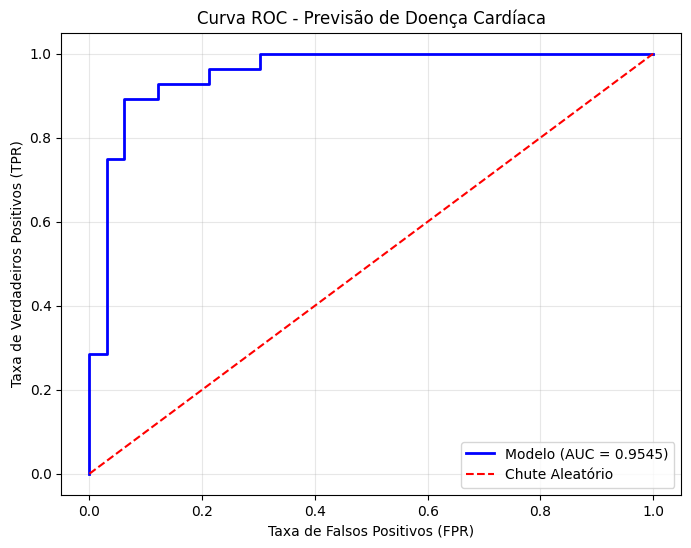

In [12]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

colunas_continuas = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
X_test[colunas_continuas] = scaler.transform(X_test[colunas_continuas])

resp = modelo.predict(X_test)
probabilidades = modelo.predict_proba(X_test)[:, 1]

acuracia = accuracy_score(Y_test, resp)
precisao = precision_score(Y_test, resp)
recall = recall_score(Y_test, resp)
f1score = f1_score(Y_test, resp)

rocauc = roc_auc_score(Y_test, probabilidades) 

print(f"Acurácia: {acuracia:.4f}")
print(f"Precisão: {precisao:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1score:.4f}")
print(f"AUC: {rocauc:.4f}")

fpr, tpr, thresholds = roc_curve(Y_test, probabilidades)

plt.figure(figsize=(8, 6))

plt.plot(fpr, tpr, color='blue', linewidth=2, label=f'Modelo (AUC = {rocauc:.4f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Chute Aleatório')

plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)')
plt.title('Curva ROC - Previsão de Doença Cardíaca')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

plt.show()